# BÀI TẬP 1 - CNN: Nhận dạng ảnh CIFAR10
**Dataset:** CIFAR10 (built-in TensorFlow)
**Kiến trúc:** Conv2D → MaxPool → Conv2D → MaxPool → Flatten → Dense

In [1]:
# BƯỚC 1: NẠP THƯ VIỆN
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout, Input
from sklearn.metrics import classification_report, confusion_matrix
print('TensorFlow:', tf.__version__)

TensorFlow: 2.20.0


In [2]:
# BƯỚC 2: ĐỌC DỮ LIỆU CIFAR10
class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
num_classes = 10
input_shape = (32, 32, 3)

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalize
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32')  / 255.0

y_train_flat = y_train.flatten()
y_test_flat  = y_test.flatten()

# One-hot encoding
y_train_cat = keras.utils.to_categorical(y_train_flat, num_classes)
y_test_cat  = keras.utils.to_categorical(y_test_flat,  num_classes)

print('X_train:', X_train.shape)
print('X_test: ', X_test.shape)
print('Classes:', num_classes)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
X_train: (50000, 32, 32, 3)
X_test:  (10000, 32, 32, 3)
Classes: 10


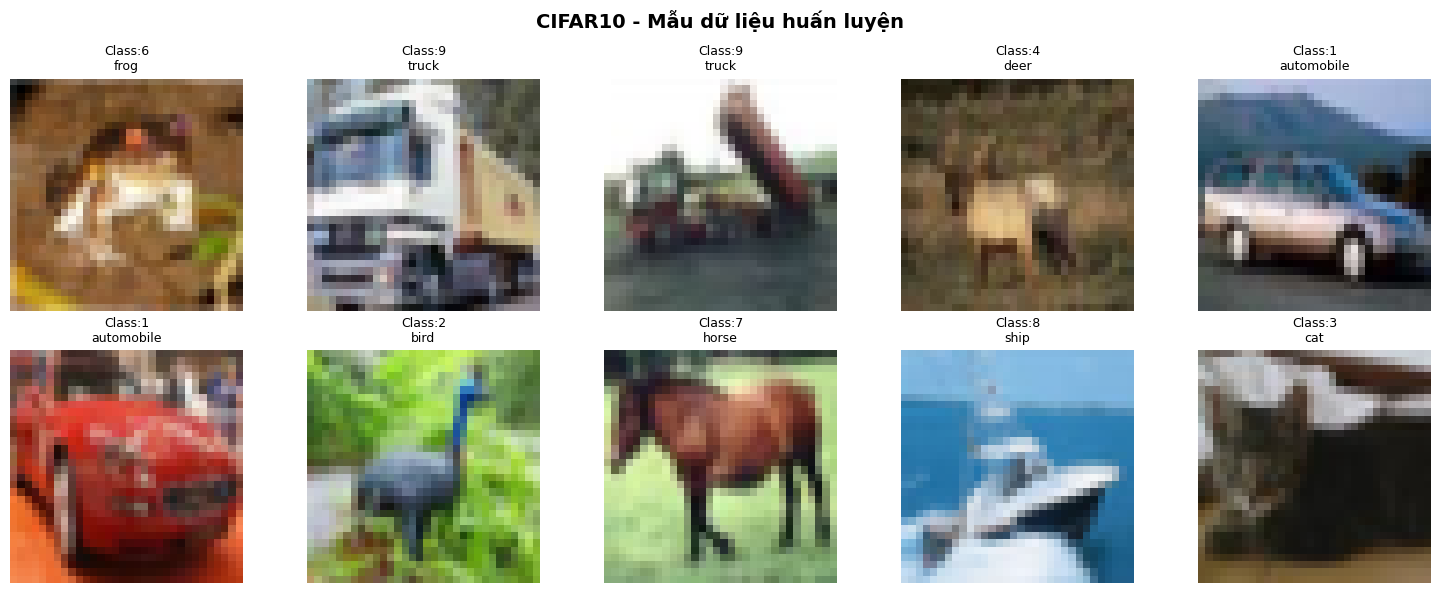

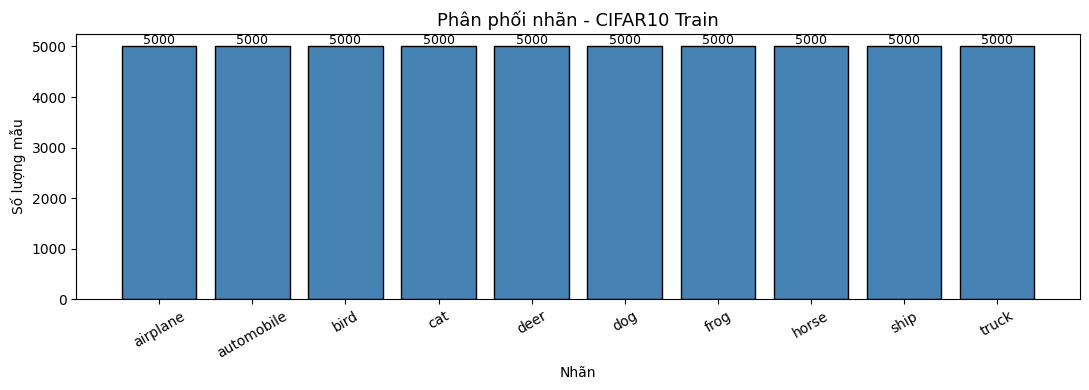

In [3]:
# BƯỚC 3: TRỰC QUAN HÓA DỮ LIỆU
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()
for i in range(10):
    axes[i].imshow(X_train[i])
    axes[i].set_title(f'Class:{y_train_flat[i]}\n{class_names[y_train_flat[i]]}', fontsize=9)
    axes[i].axis('off')
plt.suptitle('CIFAR10 - Mẫu dữ liệu huấn luyện', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Biểu đồ phân phối nhãn
unique, counts = np.unique(y_train_flat, return_counts=True)
plt.figure(figsize=(11, 4))
bars = plt.bar([class_names[i] for i in unique], counts, color='steelblue', edgecolor='black')
for bar, cnt in zip(bars, counts):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50, str(cnt), ha='center', fontsize=9)
plt.title('Phân phối nhãn - CIFAR10 Train', fontsize=13)
plt.xlabel('Nhãn')
plt.ylabel('Số lượng mẫu')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [4]:
# BƯỚC 4: XÂY DỰNG MÔ HÌNH CNN
model = Sequential([
    Input(shape=input_shape),
    Conv2D(32, kernel_size=(3,3), activation='relu'),
    MaxPool2D(pool_size=(2,2)),
    Conv2D(64, kernel_size=(3,3), activation='relu'),
    MaxPool2D(pool_size=(2,2)),
    Conv2D(128, kernel_size=(3,3), activation='relu'),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 620,362 (2.37 MB)

 Trainable params: 620,362 (2.37 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# BƯỚC 5: HUẤN LUYỆN MÔ HÌNH
model_fit = model.fit(X_train, y_train_cat,
                      validation_split=0.1,
                      epochs=20,
                      batch_size=128,
                      verbose=1)

Epoch 1/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 61s 168ms/step - accuracy: 0.4075 - loss: 1.6191 - val_accuracy: 0.5314 - val_loss: 1.3203
Epoch 2/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 82s 170ms/step - accuracy: 0.5502 - loss: 1.2587 - val_accuracy: 0.6184 - val_loss: 1.0990
Epoch 3/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 79s 161ms/step - accuracy: 0.6114 - loss: 1.0945 - val_accuracy: 0.6492 - val_loss: 1.0000
Epoch 4/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 58s 166ms/step - accuracy: 0.6546 - loss: 0.9762 - val_accuracy: 0.6778 - val_loss: 0.9238
Epoch 5/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 81s 163ms/step - accuracy: 0.6805 - loss: 0.9058 - val_accuracy: 0.6874 - val_loss: 0.8958
Epoch 6/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 83s 166ms/step - accuracy: 0.7105 - loss: 0.8272 - val_accuracy: 0.7126 - val_loss: 0.8381
Epoch 7/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 58s 164ms/step - accuracy: 0.7300 - loss: 0.7627 - val_accuracy: 0.7214 - val_loss: 0.8141
Epoch 8/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 57s 162ms/step - accuracy: 0.7494 - loss: 0

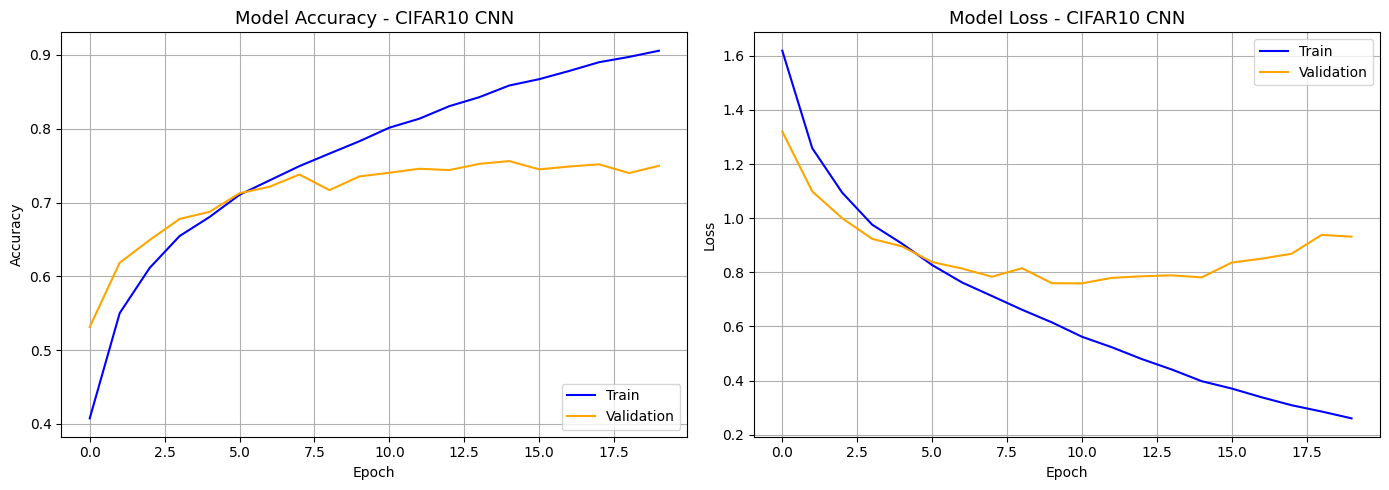

In [6]:
# BƯỚC 6: BIỂU ĐỒ ACCURACY & LOSS
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(model_fit.history['accuracy'], label='Train', color='blue')
axes[0].plot(model_fit.history['val_accuracy'], label='Validation', color='orange')
axes[0].set_title('Model Accuracy - CIFAR10 CNN', fontsize=13)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(loc='lower right'); axes[0].grid(True)

axes[1].plot(model_fit.history['loss'], label='Train', color='blue')
axes[1].plot(model_fit.history['val_loss'], label='Validation', color='orange')
axes[1].set_title('Model Loss - CIFAR10 CNN', fontsize=13)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(loc='upper right'); axes[1].grid(True)

plt.tight_layout()
plt.show()

313/313 - 7s - 22ms/step - accuracy: 0.7265 - loss: 1.0342
Test loss:     1.0341989994049072
Test accuracy: 0.7264999747276306
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step

=== Classification Report ===
              precision    recall  f1-score   support

    airplane       0.75      0.78      0.77      1000
  automobile       0.82      0.84      0.83      1000
        bird       0.62      0.64      0.63      1000
         cat       0.57      0.52      0.54      1000
        deer       0.66      0.70      0.68      1000
         dog       0.64      0.63      0.63      1000
        frog       0.79      0.78      0.79      1000
       horse       0.74      0.79      0.76      1000
        ship       0.85      0.80      0.82      1000
       truck       0.84      0.79      0.81      1000

    accuracy                           0.73     10000
   macro avg       0.73      0.73      0.73     10000
weighted avg       0.73      0.73      0.73     10000



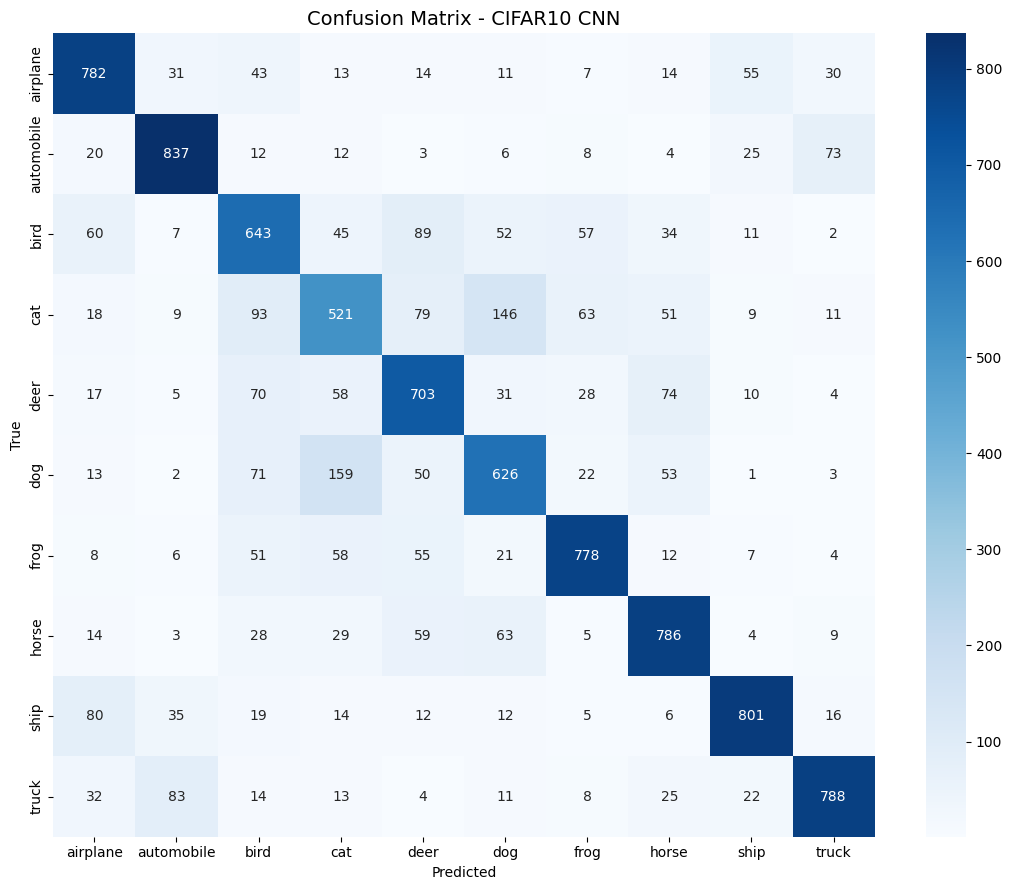

In [7]:
# BƯỚC 7: ĐÁNH GIÁ TRÊN TẬP TEST
score = model.evaluate(X_test, y_test_cat, verbose=2)
print('Test loss:    ', score[0])
print('Test accuracy:', score[1])

# Confusion Matrix
y_pred = np.argmax(model.predict(X_test), axis=1)
print('\n=== Classification Report ===')
print(classification_report(y_test_flat, y_pred, target_names=class_names))

cm = confusion_matrix(y_test_flat, y_pred)
plt.figure(figsize=(11, 9))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - CIFAR10 CNN', fontsize=14)
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Probability array: [[5.6263343e-03 1.4567327e-05 3.9642779e-04 8.6419547e-01 3.7371534e-05
  1.2017667e-01 7.5429534e-03 1.2874778e-04 1.8687550e-03 1.2695213e-05]]
Predicted: 3 | True: 3


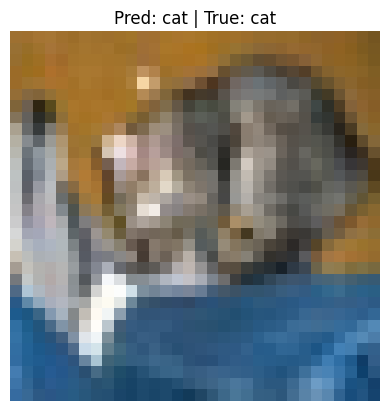

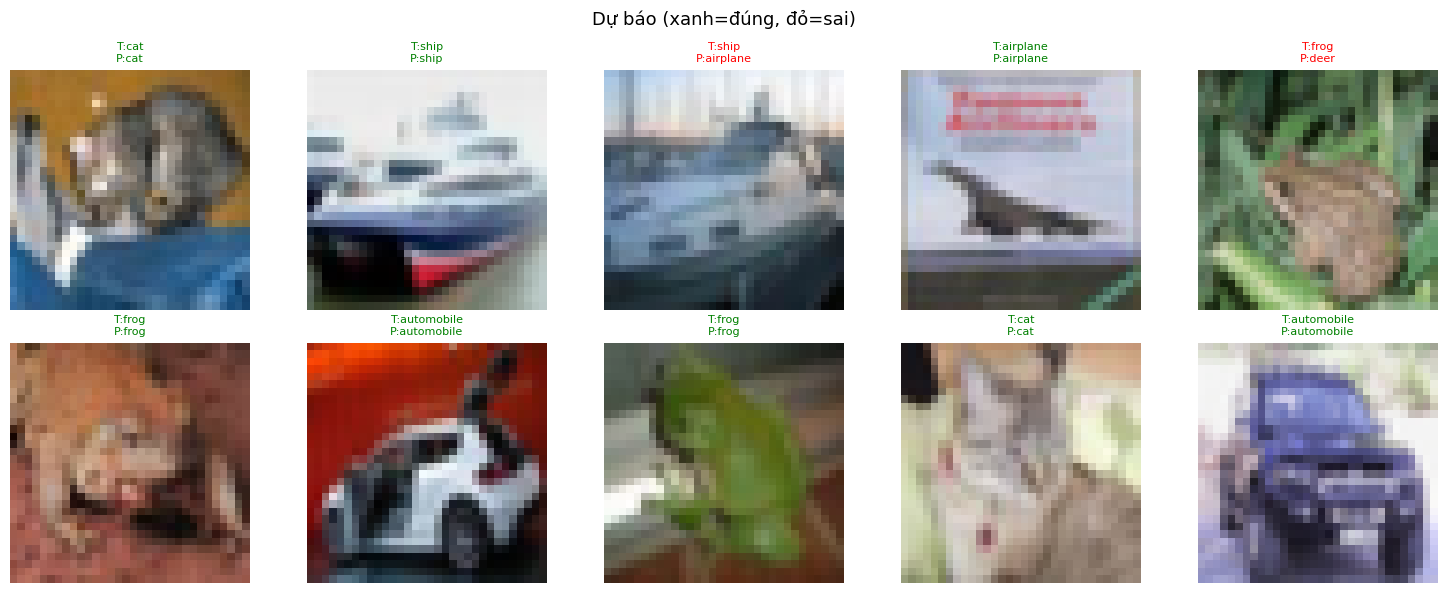

In [8]:
# BƯỚC 8: DỰ BÁO ẢNH MỚI
predict = model.predict(X_test[:1])
print('Probability array:', predict)
print('Predicted:', np.argmax(predict), '| True:', y_test_flat[0])
plt.imshow(X_test[0])
plt.title(f'Pred: {class_names[np.argmax(predict)]} | True: {class_names[y_test_flat[0]]}')
plt.axis('off')
plt.show()

# Hiển thị 10 ảnh test với kết quả dự báo
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()
for i in range(10):
    pred = np.argmax(model.predict(X_test[i:i+1], verbose=0))
    true = y_test_flat[i]
    color = 'green' if pred == true else 'red'
    axes[i].imshow(X_test[i])
    axes[i].set_title(f'T:{class_names[true]}\nP:{class_names[pred]}', color=color, fontsize=8)
    axes[i].axis('off')
plt.suptitle('Dự báo (xanh=đúng, đỏ=sai)', fontsize=13)
plt.tight_layout(); plt.show()

In [9]:
# BƯỚC 9: LƯU THAM SỐ MÔ HÌNH
model.save_weights('cnn_cifar10.weights.h5')
print('Đã lưu weights!')

Đã lưu weights!
